In [2]:
import os
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from scipy.linalg import cholesky, cho_solve, svd
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import make_s_curve, make_swiss_roll
from sklearn.preprocessing import StandardScaler



These are the graphs used in Chapter 4, which were generated seperately during the development and debugging of the statistics. For clarity to show, I collect them altogether into this single notebook. Note that the implementations of the statistics used here had not yet been integrated into the py-spoc framework at the time.

In [3]:
SHOW_FIGURES = True
SAVE_FIGURES = True

def publication_rc():
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def save_figure(fig, out_base, show=SHOW_FIGURES, save=SAVE_FIGURES):
    if not fig.get_constrained_layout():
        fig.tight_layout()
    if save:
        out_dir = os.path.dirname(out_base)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        fig.savefig(out_base + ".png", bbox_inches="tight")
        fig.savefig(out_base + ".pdf", bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

In [4]:
def linear_embed(base, p, seed=0, noise=0.0):
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(base.shape[1], p))
    Z = base @ A
    if noise > 0:
        Z = Z + noise * rng.normal(size=Z.shape)
    return Z


In [8]:
COMMON_N = 40
COMMON_P = 25


def make_helix(n=COMMON_N, p=COMMON_P, noise=0.02, turns=2.0, seed=0, embed_noise=0.01):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 2 * np.pi * turns, n)
    x = np.cos(t)
    y = np.sin(t)
    z = t / (2 * np.pi * turns) * 2 - 1
    base = np.column_stack([x, y, z]) + noise * rng.normal(size=(n, 3))
    Y = linear_embed(base, p=p, seed=seed + 1, noise=embed_noise)
    return Y, t


def make_line_embed(n=COMMON_N, p=COMMON_P, noise=0.03, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(-1, 1, n)
    base = t[:, None]
    A = rng.normal(size=(1, p))
    Y = base @ A + noise * rng.normal(size=(n, p))
    return Y, t


def make_plane_embed(n=COMMON_N, p=COMMON_P, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    u = rng.uniform(-1, 1, n)
    v = rng.uniform(-1, 1, n)
    base = np.column_stack([u, v, 0.5 * u - 0.2 * v])
    Y = linear_embed(base, p=p, seed=seed + 1, noise=noise)
    return Y, np.column_stack([u, v])


def make_scurve_embed(n=COMMON_N, p=COMMON_P, noise=0.03, seed=0, embed_noise=0.01):
    base, t = make_s_curve(n_samples=n, noise=noise, random_state=seed)
    Y = linear_embed(base, p=p, seed=seed + 1, noise=embed_noise)
    return Y, t


def make_clusters_highd(n=COMMON_N, p=COMMON_P, seed=0, sep=1.8, std=0.4):
    rng = np.random.default_rng(seed)
    centers = np.zeros((3, p))
    centers[0, :3] = [sep, sep, 0.0]
    centers[1, :3] = [-sep, -sep, 0.0]
    centers[2, :3] = [sep, -sep, 0.0]
    labels = rng.integers(0, 3, size=n)
    Y = centers[labels] + std * rng.normal(size=(n, p))
    return Y, labels


def make_gaussian_noise(n=COMMON_N, p=COMMON_P, seed=0):
    rng = np.random.default_rng(seed)
    return rng.normal(size=(n, p))



In [9]:
class GPLVMR2:
    def __init__(self, latent_dim=2, max_iters=20, n_null=5, seed=0):
        self.latent_dim = latent_dim
        self.max_iters = max_iters
        self.n_null = n_null
        self.seed = seed

    def _shuffle_rows_per_column(self, X, rng):
        A = np.array(X, copy=True)
        n, p = A.shape
        for j in range(p):
            A[:, j] = A[rng.permutation(n), j]
        return A

    def _kernel_rbf(self, X, alpha, gamma, beta):
        n = X.shape[0]
        sq_dists = squareform(pdist(X, "sqeuclidean"))
        K = alpha * np.exp(-0.5 * gamma * sq_dists)
        K += np.eye(n) * (1.0 / beta)
        return K, sq_dists

    def _objective(self, params, Y, q, n, d, return_grad=True):
        X = params[:-3].reshape(n, q)
        log_alpha, log_gamma, log_beta = params[-3:]
        log_alpha = np.clip(log_alpha, -20, 25)
        log_gamma = np.clip(log_gamma, -20, 25)
        log_beta = np.clip(log_beta, -20, 25)

        alpha = np.exp(log_alpha)
        gamma = np.exp(log_gamma)
        beta = np.exp(log_beta)
        K, sq_dists = self._kernel_rbf(X, alpha, gamma, beta)

        try:
            L = cholesky(K, lower=True)
        except np.linalg.LinAlgError:
            if return_grad:
                return np.inf, np.zeros_like(params)
            return np.inf

        K_inv_Y = cho_solve((L, True), Y)
        data_fit = -0.5 * np.trace(Y.T @ K_inv_Y)
        log_det_K = 2.0 * np.sum(np.log(np.diag(L)))
        complexity = -0.5 * d * log_det_K
        constant = -0.5 * d * n * np.log(2 * np.pi)
        log_likelihood = complexity + data_fit + constant
        log_prior = -0.5 * np.sum(X**2) - 0.5 * n * q * np.log(2 * np.pi)
        nll = -(log_likelihood + log_prior)

        if not return_grad:
            return nll

        K_inv = cho_solve((L, True), np.eye(n))
        dL_dK = 0.5 * (K_inv_Y @ K_inv_Y.T - d * K_inv)
        dNLL_dK = -dL_dK
        K_rbf = K - np.eye(n) * (1.0 / beta)

        d_alpha = np.sum(dNLL_dK * (K_rbf / alpha)) * alpha
        d_gamma = np.sum(dNLL_dK * (-0.5 * sq_dists * K_rbf)) * gamma
        d_beta = np.trace(dNLL_dK * (-1.0 / beta**2 * np.eye(n))) * beta

        G = dNLL_dK * K_rbf
        dLik_dX = np.zeros_like(X)
        for d_idx in range(q):
            dist_matrix = np.subtract.outer(X[:, d_idx], X[:, d_idx])
            dLik_dX[:, d_idx] = -gamma * np.sum(G * dist_matrix, axis=1) * 2.0

        dNLL_dX = dLik_dX + X
        grads = np.concatenate([dNLL_dX.ravel(), [d_alpha, d_gamma, d_beta]])
        return nll, grads

    def fit_score(self, data):
        Y = np.array(data, copy=True)
        if np.isnan(Y).any():
            raise ValueError("Input data contains NaN.")

        Y_std = np.std(Y)
        if Y_std < 1e-9:
            Y_std = 1.0
        Y_centered = (Y - np.mean(Y, axis=0)) / Y_std

        n, d_out = Y_centered.shape
        q = min(self.latent_dim, d_out)

        u, s, _ = svd(Y_centered, full_matrices=False)
        X_init = u[:, :q] * s[:q]
        params_init = np.concatenate([X_init.ravel(), [np.log(1.0), -np.log(q), np.log(10.0)]])

        res = minimize(
            fun=self._objective,
            x0=params_init,
            args=(Y_centered, q, n, d_out, True),
            method="L-BFGS-B",
            jac=True,
            options={"maxiter": self.max_iters},
        )

        optimized_params = res.x
        X_opt = optimized_params[:-3].reshape(n, q)
        hyperparams = optimized_params[-3:]
        nll_real = self._objective(optimized_params, Y_centered, q, n, d_out, return_grad=False)
        lpd_real = -nll_real

        rng = np.random.default_rng(self.seed)
        null_lpds = []
        null_kernels = []

        log_alpha, log_gamma, log_beta = hyperparams
        alpha = np.exp(np.clip(log_alpha, -20, 25))
        gamma = np.exp(np.clip(log_gamma, -20, 25))
        beta = np.exp(np.clip(log_beta, -20, 25))

        for _ in range(self.n_null):
            X_shuffled = self._shuffle_rows_per_column(X_opt, rng)
            params_null = np.concatenate([X_shuffled.ravel(), hyperparams])
            nll_null = self._objective(params_null, Y_centered, q, n, d_out, return_grad=False)
            null_lpds.append(-nll_null)
            Kb, _ = self._kernel_rbf(X_shuffled, alpha, gamma, beta)
            null_kernels.append(Kb)

        null_mean = float(np.mean(null_lpds))
        score = float((lpd_real - null_mean) / abs(null_mean))
        Khat, _ = self._kernel_rbf(X_opt, alpha, gamma, beta)

        return {
            "score": score,
            "q": q,
            "nit": res.nit,
            "success": bool(res.success),
            "message": res.message,
            "lpd_real": float(lpd_real),
            "lpd_null_mean": float(null_mean),
            "X_opt": X_opt,
            "Khat": Khat,
            "Kbs": null_kernels,
        }



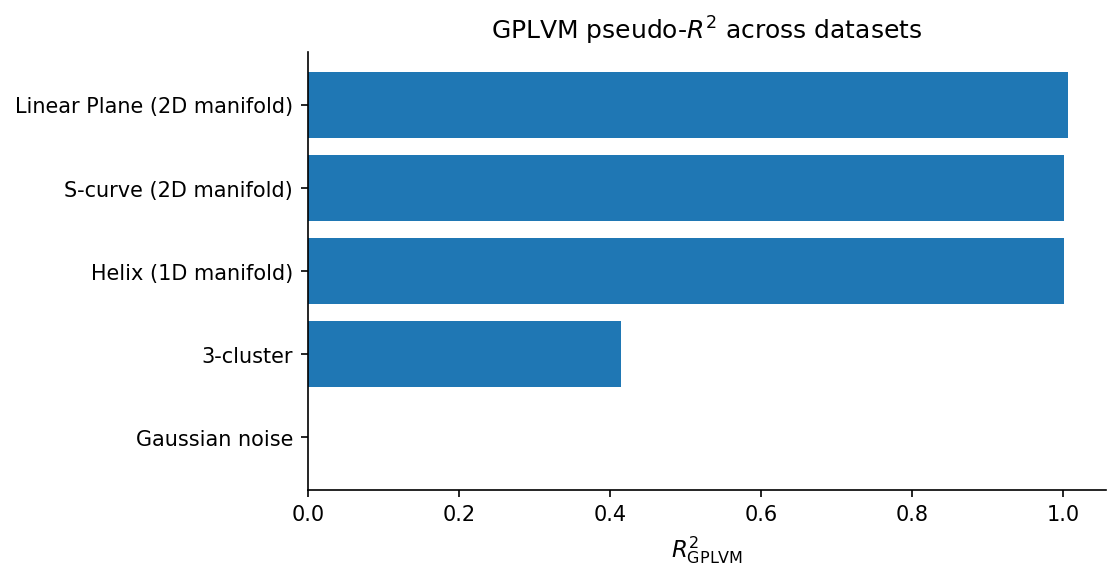

In [10]:
publication_rc()
r2_output_dir = "gplvm_r2_outputs_aligned"
os.makedirs(r2_output_dir, exist_ok=True)
r2_cache: Dict[Tuple[str, int], Dict[str, np.ndarray]] = {}


def fit_r2_cached(name, Y, q):
    key = (name, q)
    if key not in r2_cache:
        model = GPLVMR2(latent_dim=q, max_iters=20, n_null=5, seed=0)
        r2_cache[key] = model.fit_score(Y)
    return r2_cache[key]


helix_Y, helix_t = make_helix()
plane_Y, _ = make_plane_embed()
scurve_Y, _ = make_scurve_embed()
cluster_Y, _ = make_clusters_highd()
noise_Y = make_gaussian_noise()

comparison_specs = [
    ("Helix (1D manifold)", helix_Y, 2),
    ("Linear Plane (2D manifold)", plane_Y, 2),
    ("S-curve (2D manifold)", scurve_Y, 2),
    ("3-cluster", cluster_Y, 2),
    ("Gaussian noise", noise_Y, 2),
]

comparison_rows = []
for name, Y, q in comparison_specs:
    out = fit_r2_cached(name, Y, q)
    comparison_rows.append({
        "dataset": name,
        "latent_dim_q": q,
        "R2_GPLVM": out["score"],
        "real_objective": out["lpd_real"],
        "null_objective_mean": out["lpd_null_mean"],
        "optimizer_iterations": out["nit"],
    })
comparison_rows_sorted = sorted(comparison_rows, key=lambda r: r["R2_GPLVM"], reverse=True)

fig, ax = plt.subplots(figsize=(7.6, 4.0))
labels = [r["dataset"] for r in comparison_rows_sorted]
scores = [r["R2_GPLVM"] for r in comparison_rows_sorted]
ax.barh(labels, scores)
ax.invert_yaxis()
ax.set_xlabel(r"$R^2_{\mathrm{GPLVM}}$")
ax.set_title(r"GPLVM pseudo-$R^2$ across datasets")
save_figure(fig, os.path.join(r2_output_dir, "figure_1_dataset_scores"))



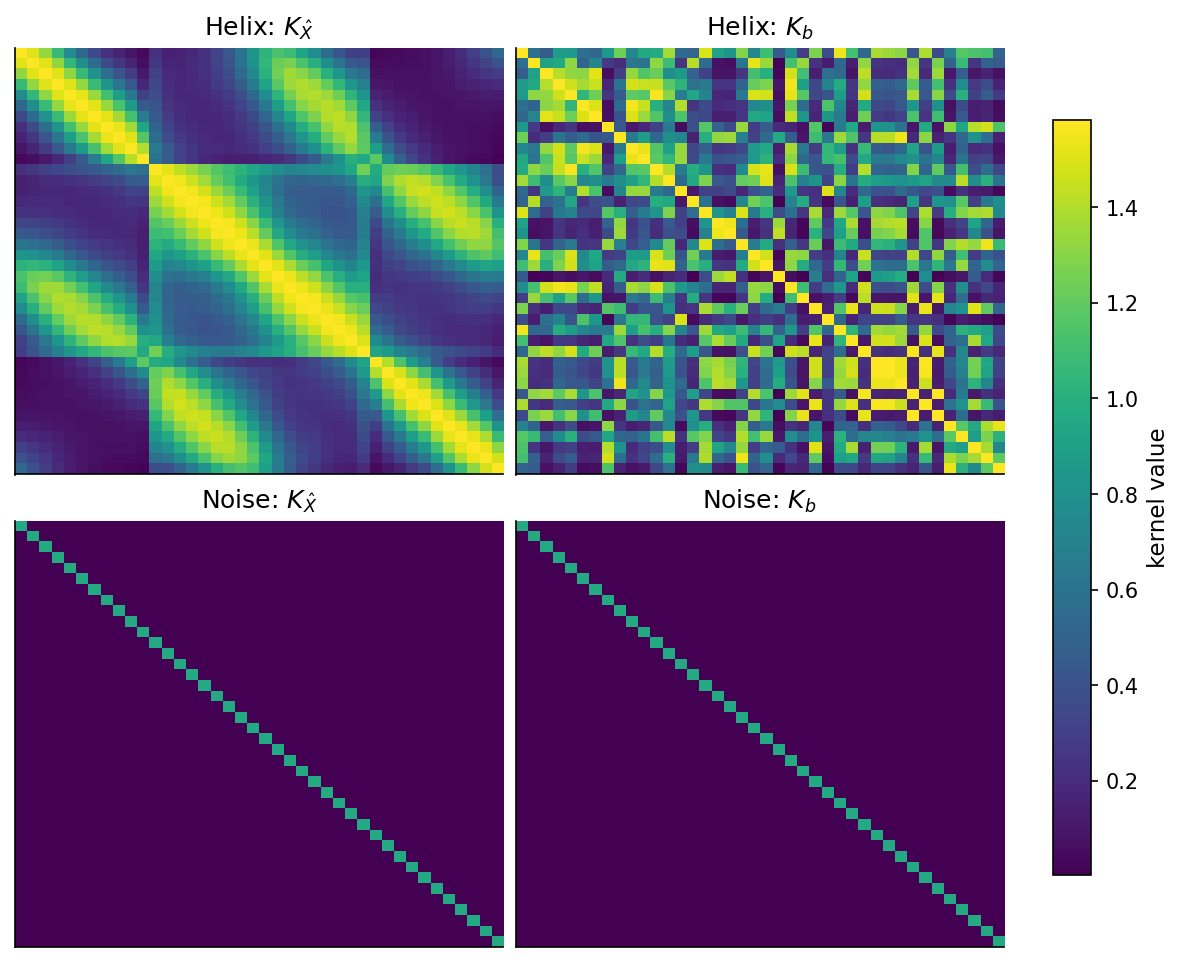

In [11]:
high_name = "Helix (1D manifold)"
low_name = "Gaussian noise"
high_out = fit_r2_cached(high_name, helix_Y, 2)
low_out = fit_r2_cached(low_name, noise_Y, 2)

high_order = np.arange(helix_Y.shape[0])
low_order = np.arange(noise_Y.shape[0])
matrices = [
    high_out["Khat"][np.ix_(high_order, high_order)],
    high_out["Kbs"][0][np.ix_(high_order, high_order)],
    low_out["Khat"][np.ix_(low_order, low_order)],
    low_out["Kbs"][0][np.ix_(low_order, low_order)],
]
vmin = min(M.min() for M in matrices)
vmax = max(M.max() for M in matrices)

fig, axs = plt.subplots(2, 2, figsize=(7.8, 6.3), constrained_layout=True)
titles = [
    r"Helix: $K_{\hat X}$",
    r"Helix: $K_b$",
    r"Noise: $K_{\hat X}$",
    r"Noise: $K_b$",
]
images = []
for ax, M, title in zip(axs.flat, matrices, titles):
    im = ax.imshow(M, aspect="auto", vmin=vmin, vmax=vmax)
    images.append(im)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
cbar = fig.colorbar(images[-1], ax=axs, shrink=0.84, location="right")
cbar.set_label("kernel value")
save_figure(fig, os.path.join(r2_output_dir, "figure_2_kernel_heatmaps"))



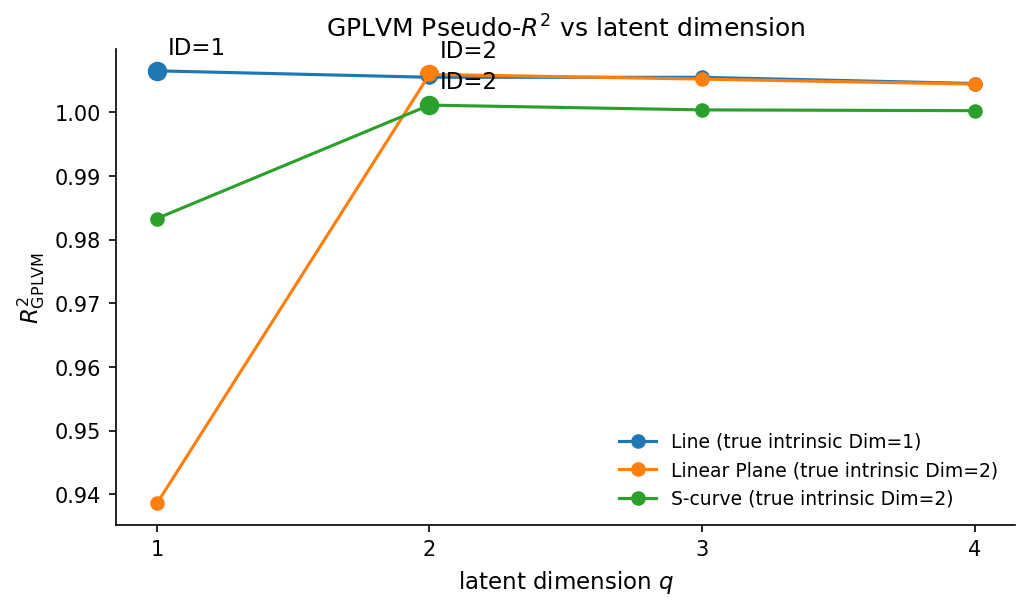

In [12]:
curve_specs = [
    ("Line", make_line_embed()[0], 1),
    ("Linear Plane", plane_Y, 2),
    ("S-curve", scurve_Y, 2),
]
q_values = [1, 2, 3, 4]
r2_curves = {}

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for name, Y, true_dim in curve_specs:
    curve_scores = []
    for q in q_values:
        out = fit_r2_cached(name, Y, q)
        curve_scores.append(out["score"])
    r2_curves[name] = curve_scores
    ax.plot(q_values, curve_scores, marker="o", label=f"{name} (true intrinsic Dim={true_dim})")
    ax.scatter([true_dim], [curve_scores[q_values.index(true_dim)]], s=70)
    ax.annotate(
        f"ID={true_dim}",
        xy=(true_dim, curve_scores[q_values.index(true_dim)]),
        xytext=(5, 8),
        textcoords="offset points",
    )

ax.set_xlabel(r"latent dimension $q$")
ax.set_ylabel(r"$R^2_{\mathrm{GPLVM}}$")
ax.set_title(r"GPLVM Pseudo-$R^2$ vs latent dimension")
ax.set_xticks(q_values)
ax.legend(loc="best", frameon=False)
save_figure(fig, os.path.join(r2_output_dir, "figure_3_r2_vs_q"))



In [13]:
class GPLVMDoFCore:
    def __init__(self, latent_dim=3, max_iters=50, normalize=True):
        self.latent_dim = latent_dim
        self.max_iters = max_iters
        self.normalize = normalize

    @staticmethod
    def _kernel_rbf(X, alpha, gamma, beta):
        n = X.shape[0]
        sq_dists = squareform(pdist(X, "sqeuclidean"))
        K = alpha * np.exp(-0.5 * gamma * sq_dists)
        K += np.eye(n) * (1.0 / beta)
        return K, sq_dists

    @staticmethod
    def _clean_kernel(X, alpha, gamma):
        sq_dists = squareform(pdist(X, "sqeuclidean"))
        return alpha * np.exp(-0.5 * gamma * sq_dists)

    def _objective(self, params, Y, q, n, d_out, return_grad=True):
        X = params[:-3].reshape(n, q)
        log_alpha, log_gamma, log_beta = params[-3:]
        log_alpha = np.clip(log_alpha, -20, 25)
        log_gamma = np.clip(log_gamma, -20, 25)
        log_beta = np.clip(log_beta, -20, 25)

        alpha = np.exp(log_alpha)
        gamma = np.exp(log_gamma)
        beta = np.exp(log_beta)
        K, sq_dists = self._kernel_rbf(X, alpha, gamma, beta)

        try:
            L = cholesky(K, lower=True)
        except np.linalg.LinAlgError:
            if return_grad:
                return 1e100, np.zeros_like(params)
            return 1e100

        K_inv_Y = cho_solve((L, True), Y)
        data_fit = -0.5 * np.trace(Y.T @ K_inv_Y)
        log_det_K = 2.0 * np.sum(np.log(np.diag(L)))
        complexity = -0.5 * d_out * log_det_K
        constant = -0.5 * d_out * n * np.log(2 * np.pi)
        log_likelihood = data_fit + complexity + constant
        log_prior = -0.5 * np.sum(X**2) - 0.5 * n * q * np.log(2 * np.pi)
        nll = -(log_likelihood + log_prior)

        if not return_grad:
            return nll

        K_inv = cho_solve((L, True), np.eye(n))
        dL_dK = 0.5 * (K_inv_Y @ K_inv_Y.T - d_out * K_inv)
        dNLL_dK = -dL_dK
        K_rbf = K - np.eye(n) * (1.0 / beta)

        d_alpha = np.sum(dNLL_dK * (K_rbf / alpha)) * alpha
        d_gamma = np.sum(dNLL_dK * (-0.5 * sq_dists * K_rbf)) * gamma
        d_beta = np.trace(dNLL_dK * (-1.0 / beta**2 * np.eye(n))) * beta

        G = dNLL_dK * K_rbf
        dLik_dX = np.zeros_like(X)
        for j in range(q):
            dist_matrix = np.subtract.outer(X[:, j], X[:, j])
            dLik_dX[:, j] = -gamma * np.sum(G * dist_matrix, axis=1) * 2.0

        dNLL_dX = dLik_dX + X
        grads = np.concatenate([dNLL_dX.ravel(), [d_alpha, d_gamma, d_beta]])
        if np.isnan(grads).any() or np.isinf(grads).any():
            return 1e100, np.zeros_like(params)
        return nll, grads

    def _preprocess(self, Y):
        Y = np.array(Y, copy=True, dtype=float)
        if self.normalize:
            Y_std = np.std(Y)
            if Y_std < 1e-9:
                Y_std = 1.0
            Y = (Y - np.mean(Y, axis=0)) / Y_std
        return Y

    def fit(self, data):
        Y = self._preprocess(data)
        if np.isnan(Y).any():
            raise ValueError("Input contains NaN.")

        n, d_out = Y.shape
        q = min(self.latent_dim, d_out)
        u, s, _ = svd(Y, full_matrices=False)
        X_init = u[:, :q] * s[:q]
        params_init = np.concatenate([X_init.ravel(), [np.log(1.0), -np.log(q), np.log(10.0)]])

        res = minimize(
            fun=self._objective,
            x0=params_init,
            args=(Y, q, n, d_out, True),
            method="L-BFGS-B",
            jac=True,
            options={"maxiter": self.max_iters},
        )

        params_opt = res.x
        X_opt = params_opt[:-3].reshape(n, q)
        log_alpha, log_gamma, log_beta = params_opt[-3:]
        log_alpha = np.clip(log_alpha, -20, 25)
        log_gamma = np.clip(log_gamma, -20, 25)
        log_beta = np.clip(log_beta, -20, 25)

        alpha = np.exp(log_alpha)
        gamma = np.exp(log_gamma)
        beta = np.exp(log_beta)
        sigma2 = 1.0 / beta
        K_clean = self._clean_kernel(X_opt, alpha, gamma)
        eigvals = np.maximum(np.linalg.eigvalsh(K_clean), 0.0)
        dof = np.sum(eigvals / (eigvals + sigma2))
        dof_norm = dof / n

        return {
            "dof": float(dof),
            "dof_norm": float(dof_norm),
            "alpha": float(alpha),
            "gamma": float(gamma),
            "beta": float(beta),
            "sigma2": float(sigma2),
            "log_alpha": float(log_alpha),
            "log_gamma": float(log_gamma),
            "log_beta": float(log_beta),
            "eigvals": eigvals,
            "X_opt": X_opt,
            "success": bool(res.success),
            "nit": int(res.nit),
            "message": str(res.message),
        }



In [14]:
class SyntheticDataGenerator:
    def __init__(self, n_samples=80, n_features=20, random_state=42):
        self.n = n_samples
        self.p = n_features
        self.rng = np.random.RandomState(random_state)
        self.datasets = {}

    def _project_to_high_dim(self, X_low):
        d = X_low.shape[1]
        Q, _ = np.linalg.qr(self.rng.randn(self.p, d))
        X_high = X_low @ Q.T
        return StandardScaler().fit_transform(X_high)

    def generate_selected(self):
        X_low = self.rng.randn(self.n, 3)
        self.datasets["Linear Plane"] = (self._project_to_high_dim(X_low), X_low[:, 0])

        X_low, t = make_swiss_roll(n_samples=self.n, noise=0.0, random_state=self.rng)
        self.datasets["Swiss Roll"] = (self._project_to_high_dim(X_low), t)

        X_low, t = make_s_curve(n_samples=self.n, noise=0.0, random_state=self.rng)
        self.datasets["S-Curve"] = (self._project_to_high_dim(X_low), t)

        t = np.linspace(0, 4 * np.pi, self.n)
        x = np.cos(t)
        y = np.sin(t)
        z = 0.1 * t
        X_low = np.stack([x, y, z], axis=1)
        self.datasets["Helix"] = (self._project_to_high_dim(X_low), t)

        X_noise = self.rng.randn(self.n, self.p)
        self.datasets["Pure Gaussian Noise"] = (X_noise, np.zeros(self.n))
        return self.datasets

    def add_noise(self, X_clean, noise_level=0.1):
        noise = self.rng.randn(*X_clean.shape) * noise_level
        return X_clean + noise



In [15]:
spectrum_dataset_name = "Swiss Roll"
spectrum_noise_level = 0.0
spectrum_output_dir = "kernel_spectrum_outputs"
os.makedirs(spectrum_output_dir, exist_ok=True)

gen = SyntheticDataGenerator(n_samples=80, n_features=20, random_state=42)
datasets = gen.generate_selected()

if spectrum_dataset_name not in datasets:
    raise ValueError(f"Unknown dataset_name: {spectrum_dataset_name}. Available: {list(datasets.keys())}")

X_clean_manifold, _ = datasets[spectrum_dataset_name]
X_clean_noise, _ = datasets["Pure Gaussian Noise"]
X_noisy_manifold = gen.add_noise(X_clean_manifold, noise_level=spectrum_noise_level)
X_noisy_noise = gen.add_noise(X_clean_noise, noise_level=spectrum_noise_level)

fit_manifold = GPLVMDoFCore(latent_dim=3, max_iters=50, normalize=True).fit(X_noisy_manifold)
fit_noise = GPLVMDoFCore(latent_dim=3, max_iters=50, normalize=True).fit(X_noisy_noise)



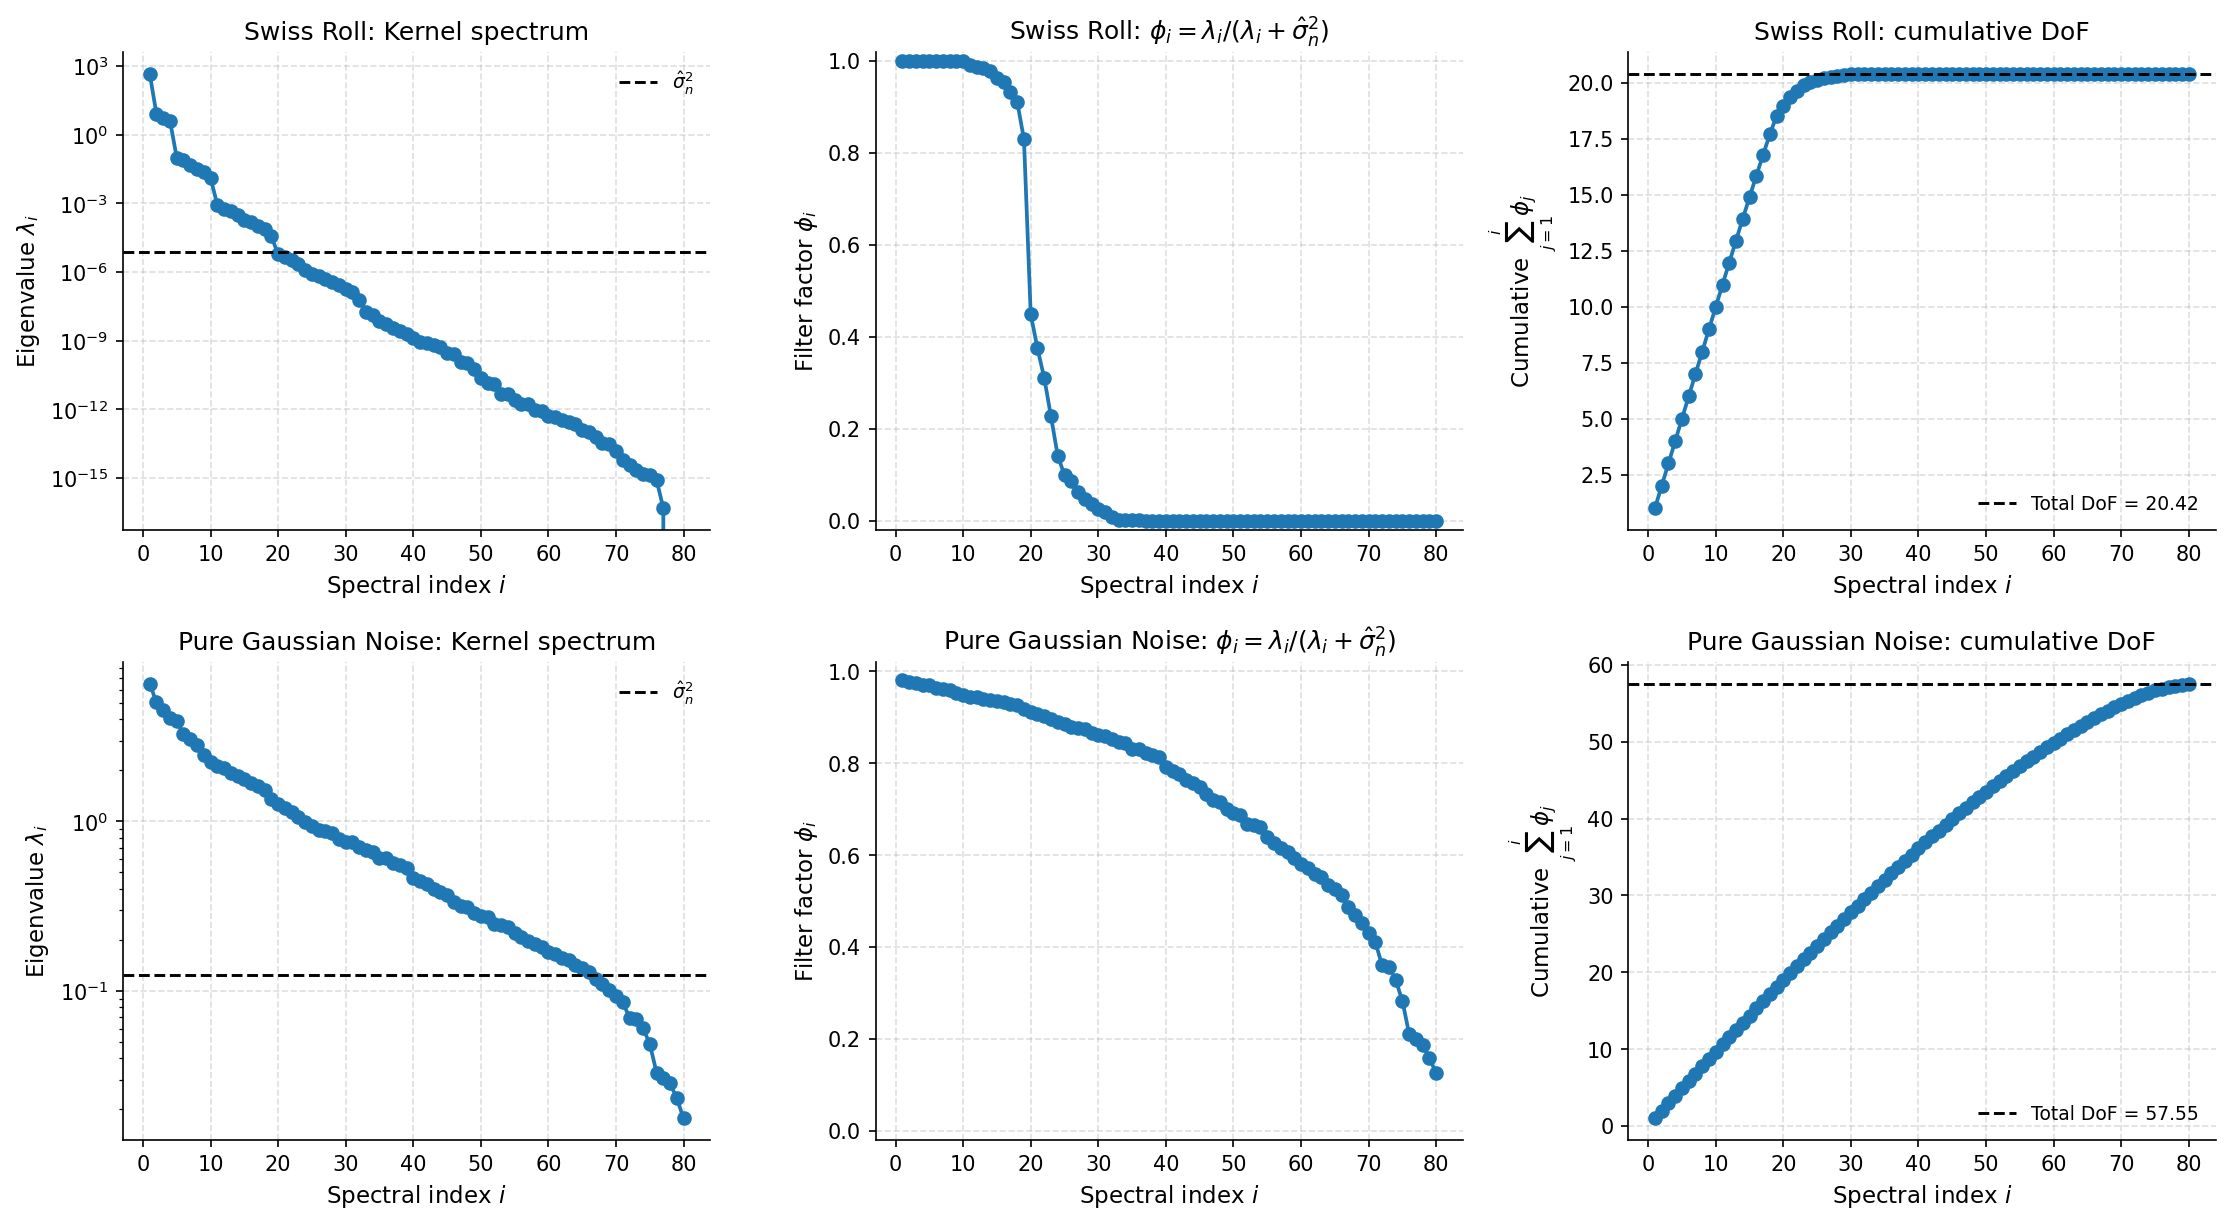

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.3))
spectrum_stats = {}
for ax_row, fit_result, title_prefix, key in [
    (axes[0, :], fit_manifold, spectrum_dataset_name, "manifold"),
    (axes[1, :], fit_noise, "Pure Gaussian Noise", "noise"),
]:
    eigvals = np.array(fit_result["eigvals"], dtype=float)
    eigvals = np.sort(np.maximum(eigvals, 0.0))[::-1]
    sigma2 = float(fit_result["sigma2"])
    phi = eigvals / (eigvals + sigma2)
    cum_phi = np.cumsum(phi)
    dof = float(np.sum(phi))
    dof_norm = float(dof / len(eigvals))
    idx = np.arange(1, len(eigvals) + 1)

    ax_row[0].plot(idx, eigvals, marker="o", linewidth=1.8)
    ax_row[0].axhline(sigma2, linestyle="--", linewidth=1.4, color="black", label=r"$\hat{\sigma}_n^2$")
    ax_row[0].set_yscale("log")
    ax_row[0].set_xlabel("Spectral index $i$")
    ax_row[0].set_ylabel(r"Eigenvalue $\lambda_i$")
    ax_row[0].set_title(rf"{title_prefix}: Kernel spectrum")
    ax_row[0].legend(frameon=False)
    ax_row[0].grid(True, linestyle="--", alpha=0.4)

    ax_row[1].plot(idx, phi, marker="o", linewidth=1.8)
    ax_row[1].set_xlabel("Spectral index $i$")
    ax_row[1].set_ylabel(r"Filter factor $\phi_i$")
    ax_row[1].set_ylim(-0.02, 1.02)
    ax_row[1].set_title(rf"{title_prefix}: $\phi_i=\lambda_i/(\lambda_i+\hat{{\sigma}}_n^2)$")
    ax_row[1].grid(True, linestyle="--", alpha=0.4)

    ax_row[2].plot(idx, cum_phi, marker="o", linewidth=1.8)
    ax_row[2].axhline(dof, linestyle="--", linewidth=1.4, color="black", label=rf"Total DoF = {dof:.2f}")
    ax_row[2].set_xlabel("Spectral index $i$")
    ax_row[2].set_ylabel(r"Cumulative $\sum_{j=1}^i \phi_j$")
    ax_row[2].set_title(rf"{title_prefix}: cumulative DoF")
    ax_row[2].legend(frameon=False)
    ax_row[2].grid(True, linestyle="--", alpha=0.4)

    spectrum_stats[key] = {
        "eigvals": eigvals,
        "phi": phi,
        "cum_phi": cum_phi,
        "sigma2": sigma2,
        "dof": dof,
        "dof_norm": dof_norm,
    }

fig.tight_layout()
safe_name = spectrum_dataset_name.lower().replace(" ", "_").replace("/", "_")
spectrum_out_base = os.path.join(spectrum_output_dir, f"{safe_name}_vs_pure_noise_spectrum_filter_factors")
fig.savefig(spectrum_out_base + ".pdf", bbox_inches="tight")

plt.show()
plt.close(fig)




[Processing noise level: 0.05]
  -> Linear Plane: beta=495.437582, alpha=155634300.415855, gamma=0.000000, success=False
  -> Swiss Roll: beta=406.779947, alpha=723929249.539281, gamma=0.000000, success=True
  -> S-Curve: beta=466.630343, alpha=12694533.709530, gamma=0.000001, success=False
  -> Helix: beta=460.900236, alpha=72004899337.385880, gamma=0.000000, success=False
  -> Pure Gaussian Noise: beta=3.702621, alpha=0.872764, gamma=19.359128, success=False

[Processing noise level: 0.1]
  -> Linear Plane: beta=128.037401, alpha=72004899337.385880, gamma=0.000000, success=True
  -> Swiss Roll: beta=108.873139, alpha=72004899337.385880, gamma=0.000000, success=True
  -> S-Curve: beta=109.865005, alpha=355719549.245391, gamma=0.000000, success=True
  -> Helix: beta=123.311343, alpha=72004899337.385880, gamma=0.000000, success=True
  -> Pure Gaussian Noise: beta=3.820903, alpha=0.838468, gamma=25.938878, success=False

[Processing noise level: 0.15]
  -> Linear Plane: beta=53.576720, 

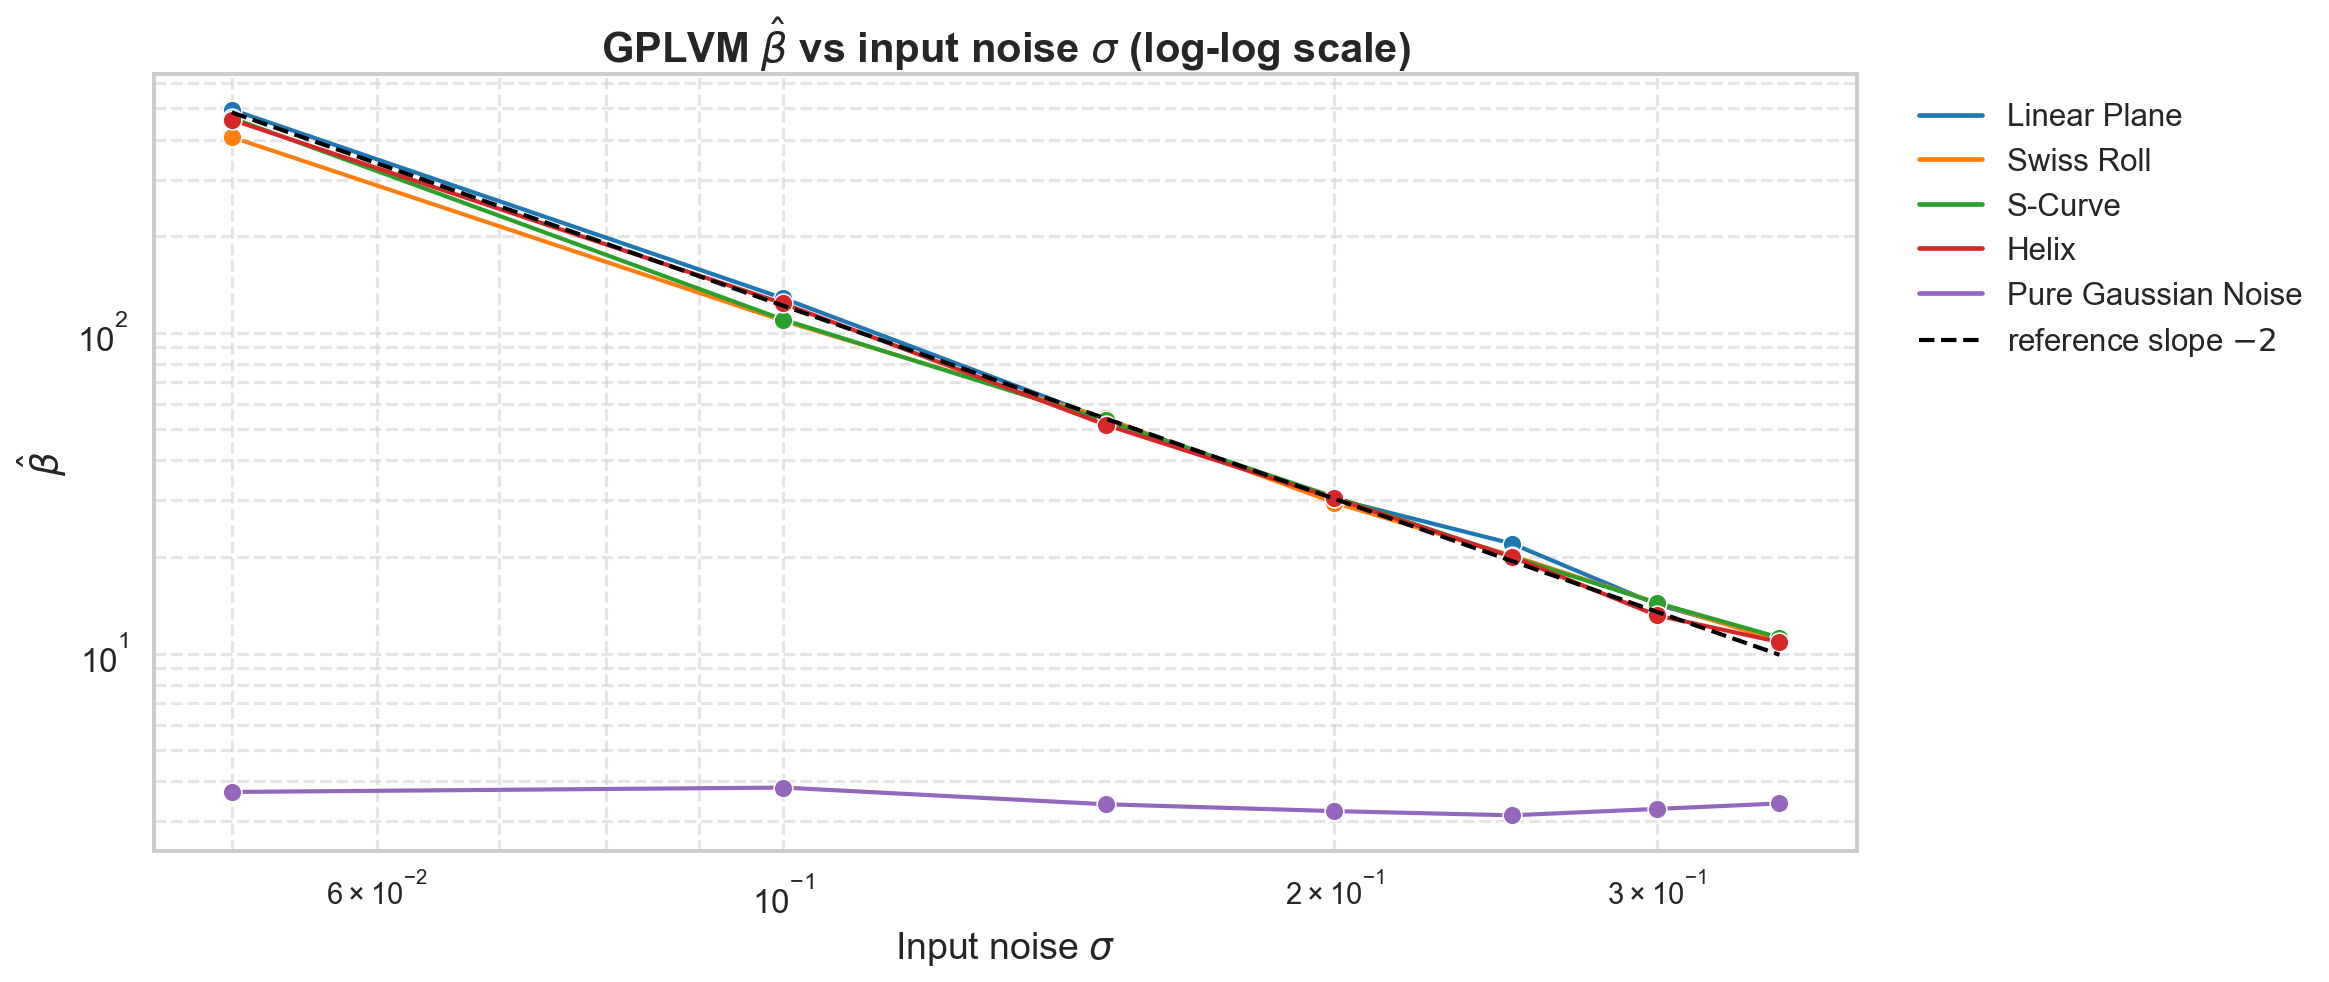

In [17]:
beta_results = []
beta_noise_levels = (0.05, 0.1, 0.15, 0.20, 0.25, 0.30, 0.35)


for noise in beta_noise_levels:
    print(f"\n[Processing noise level: {noise}]")
    gen = SyntheticDataGenerator(n_samples=100, n_features=20, random_state=40)
    datasets = gen.generate_selected()

    for name, (X_clean, _) in datasets.items():
        X_noisy = gen.add_noise(X_clean, noise_level=noise)
        fit = GPLVMDoFCore(latent_dim=3, max_iters=50, normalize=True).fit(X_noisy)

        beta_results.append({
            "Dataset": name,
            "Noise_Input": float(noise),
            "Beta": float(fit["beta"]),
            "Log_Beta": float(np.log(fit["beta"])),
            "Alpha": float(fit["alpha"]),
            "Gamma": float(fit["gamma"]),
            "Sigma2": float(fit["sigma2"]),
            "Success": bool(fit["success"]),
            "Iterations": int(fit["nit"]),
        })

        print(
            f"  -> {name}: "
            f"beta={fit['beta']:.6f}, "
            f"alpha={fit['alpha']:.6f}, "
            f"gamma={fit['gamma']:.6f}, "
            f"success={fit['success']}"
        )

df_beta = pd.DataFrame(beta_results)
df_beta.to_csv("beta_vs_noise_results.csv", index=False)

plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.2)
palette = sns.color_palette("tab10", n_colors=df_beta["Dataset"].nunique())

sns.lineplot(
    data=df_beta,
    x="Noise_Input",
    y="Beta",
    hue="Dataset",
    palette=palette,
    marker="o",
    linewidth=2,
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input noise $\\sigma$", fontsize=18)
plt.ylabel(r"$\hat{\beta}$", fontsize=18)
plt.title(r"GPLVM $\hat{\beta}$ vs input noise $\sigma$ (log-log scale)", fontsize=20, fontweight="bold")

candidate_names = [d for d in df_beta["Dataset"].unique() if "noise" not in d.lower()]
ref_dataset = candidate_names[0] if len(candidate_names) > 0 else df_beta["Dataset"].unique()[0]
ref_df = df_beta[df_beta["Dataset"] == ref_dataset].sort_values("Noise_Input")
mid_idx = len(ref_df) // 2
x0 = ref_df["Noise_Input"].iloc[mid_idx]
y0 = ref_df["Beta"].iloc[mid_idx]
x_min = df_beta["Noise_Input"].min()
x_max = df_beta["Noise_Input"].max()
x_ref = np.logspace(np.log10(x_min), np.log10(x_max), 200)
y_ref = y0 * (x_ref / x0) ** (-2)

plt.plot(x_ref, y_ref, linestyle="--", linewidth=2, color="black", label=r"reference slope $-2$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tick_params(axis="both", which="major", labelsize=16)
plt.tick_params(axis="both", which="minor", labelsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=15, title_fontsize=16)
plt.tight_layout()
plt.savefig("beta_vs_noise_loglog.pdf", bbox_inches="tight")

plt.show()



In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import gpytorch

def make_high_dim_swiss_roll(n=400, d_out=30, noise=0.03, seed=0):
    rng = np.random.default_rng(seed)
    Z, _ = make_swiss_roll(n_samples=n, noise=noise, random_state=seed)
    Z = Z / np.std(Z, axis=0, keepdims=True)
    A = rng.normal(size=(3, d_out))
    Y = np.tanh(Z @ A / np.sqrt(3.0))
    Y += 0.05 * rng.normal(size=Y.shape)
    Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0) + 1e-8)
    return Y.astype(np.float32)

In [19]:
class BayesianGPLVM(gpytorch.models.ApproximateGP):
    def __init__(self, n, d_out, latent_dim, X_init, n_inducing=40):
        inducing_points = torch.randn(d_out, n_inducing, latent_dim)
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            n_inducing,
            batch_shape=torch.Size([d_out]),
        )
        variational_strategy = gpytorch.variational.IndependentMultitaskVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_tasks=d_out,
        )

        super().__init__(variational_strategy)
        self.q_mu = nn.Parameter(X_init.clone())
        self.q_log_std = nn.Parameter(torch.ones(n, latent_dim) * -2.0)
        self.mean_module = gpytorch.means.ZeroMean(batch_shape=torch.Size([d_out]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=latent_dim, batch_shape=torch.Size([d_out])),
            batch_shape=torch.Size([d_out]),
        )

    def forward(self, X):
        mean_x = self.mean_module(X)
        covar_x = self.covar_module(X)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    def sample_latent(self):
        q_std = torch.exp(self.q_log_std)
        eps = torch.randn_like(self.q_mu)
        return self.q_mu + q_std * eps

    def kl_x(self):
        q_std = torch.exp(self.q_log_std)
        return -0.5 * torch.sum(1 + 2 * self.q_log_std - self.q_mu.pow(2) - q_std.pow(2))



Iteration 050, loss = 32.9462
Iteration 100, loss = 7.8960
Iteration 150, loss = 2.2231
Iteration 200, loss = 0.5011
Iteration 250, loss = -0.3522
Iteration 300, loss = -1.3332


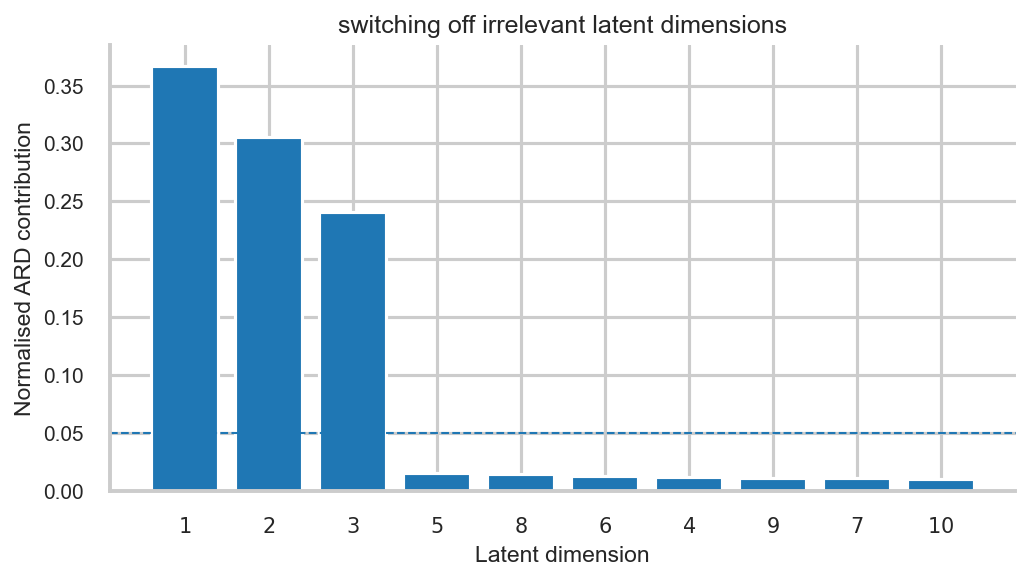


Mean inverse lengthscales:
latent dim 1: 0.2650
latent dim 2: 0.2395
latent dim 3: 0.2169
latent dim 5: 0.1002
latent dim 8: 0.1001
latent dim 6: 0.1004
latent dim 4: 0.0996
latent dim 9: 0.0973
latent dim 7: 0.0991
latent dim 10: 0.0998

Normalised ARD contributions:
latent dim 1: 0.3667
latent dim 2: 0.3059
latent dim 3: 0.2411
latent dim 5: 0.0153
latent dim 8: 0.0140
latent dim 6: 0.0128
latent dim 4: 0.0118
latent dim 9: 0.0112
latent dim 7: 0.0108
latent dim 10: 0.0104


In [20]:
publication_rc()
def train_and_plot_ard_bars(
    n=400,
    d_out=30,
    latent_dim=10,
    n_inducing=40,
    max_iters=300,
    lr=0.05,
    seed=0
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    Y = make_high_dim_swiss_roll(n=n, d_out=d_out, seed=seed)
    Y_tensor = torch.tensor(Y, dtype=torch.float32)

    # PCA initialisation
    u, s, v = torch.pca_lowrank(Y_tensor, q=latent_dim, center=False, niter=5)
    X_init = u * s

    model = BayesianGPLVM(
        n=n,
        d_out=d_out,
        latent_dim=latent_dim,
        X_init=X_init,
        n_inducing=n_inducing
    )

    likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=d_out)

    model.train()
    likelihood.train()

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=n)

    optimizer = optim.Adam(
        list(model.parameters()) + list(likelihood.parameters()),
        lr=lr
    )

    for i in range(max_iters):
        optimizer.zero_grad()

        X_sample = model.sample_latent()
        output = model(X_sample)

        loss_gp = -mll(output, Y_tensor)
        loss_kl_x = model.kl_x() / n
        loss = loss_gp + loss_kl_x

        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            print(f"Iteration {i+1:03d}, loss = {loss.item():.4f}")

    model.eval()
    likelihood.eval()

    with torch.no_grad():
        # [d_out, 1, latent_dim]
        lengthscale = model.covar_module.base_kernel.lengthscale.squeeze(1)
        mean_lengthscale = lengthscale.mean(dim=0)

        inverse_lengthscale = 1.0 / mean_lengthscale

        latent_std = model.q_mu.std(dim=0)

        # Combined ARD relevance score
        ard_score = inverse_lengthscale * latent_std
        contribution = ard_score / ard_score.sum()

        order = torch.argsort(contribution, descending=True)

        sorted_contribution = contribution[order].cpu().numpy()
        sorted_inv_lengthscale = inverse_lengthscale[order].cpu().numpy()
        sorted_dims = order.cpu().numpy() + 1

    # Plot contribution ratio
    plt.figure(figsize=(7, 4))
    plt.bar(np.arange(1, latent_dim + 1), sorted_contribution)
    plt.axhline(0.05, linestyle="--", linewidth=1)

    plt.xticks(
        np.arange(1, latent_dim + 1),
        [f"${j}$" for j in sorted_dims]
    )

    plt.xlabel("Latent dimension")
    plt.ylabel("Normalised ARD contribution")
    plt.title("switching off irrelevant latent dimensions")
    plt.tight_layout()
    plt.savefig("ard switch off.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    print("\nMean inverse lengthscales:")
    for j, val in zip(sorted_dims, sorted_inv_lengthscale):
        print(f"latent dim {j}: {val:.4f}")

    print("\nNormalised ARD contributions:")
    for j, val in zip(sorted_dims, sorted_contribution):
        print(f"latent dim {j}: {val:.4f}")


train_and_plot_ard_bars()